In [16]:
import numpy as np
import pandas as pd

# Устанавливаем сид для воспроизводимости
np.random.seed(42)

# Параметры
n_records = 50000
living_wage = 15428  # Прожиточный минимум
SDD_border_multiplier_108 = 1.1
SDD_border_multiplier_116 = 2

# Генерация family_size
family_size = np.zeros(n_records, dtype=int)
child_number = np.zeros(n_records, dtype=int)
for i in range(n_records):
    # family_size: минимум 2 (1 ребенок + 1 родитель), максимум 10
    family_size[i] = np.random.choice(
        [2, 3, 4, 5, 6, 7, 8, 9, 10],
        p=[0.15, 0.25, 0.25, 0.20, 0.10, 0.03, 0.01, 0.005, 0.005]
    )
    # child_number: от 1 до числа детей (family_size - 1 или 2 родителя)
    max_children = family_size[i] - np.random.choice([1, 2], p=[0.3, 0.7]) # 30% — 1 родитель, 70% — 2
    child_number[i] = np.random.randint(1, max_children + 1) if max_children > 0 else 1

# Генерация данных
data = {
    'age': np.random.randint(0, 18, n_records),
    'child_number': child_number,
    'family_size': family_size,
    'income_childEveryMonthPosob_Oro': np.zeros(n_records),
    'income_edvThirdChild': np.zeros(n_records),
    'study_certificate': np.zeros(n_records, dtype=int),
    'service_108': np.zeros(n_records, dtype=int),
    'service_116': np.zeros(n_records, dtype=int)
}

# Генерация доходов
for i in range(n_records):
    # Для income_childEveryMonthPosob_Oro
    mu_108 = living_wage * data['family_size'][i] * SDD_border_multiplier_108
    sigma_108 = 0.4
    data['income_childEveryMonthPosob_Oro'][i] = np.round(
        np.clip(np.random.lognormal(np.log(mu_108), sigma_108), 0, 3 * mu_108), 2
    )

    # Для income_edvThirdChild
    mu_116 = living_wage * data['family_size'][i] * SDD_border_multiplier_116
    sigma_116 = 0.4
    data['income_edvThirdChild'][i] = np.round(
        np.clip(np.random.lognormal(np.log(mu_116), sigma_116), 0, 3 * mu_116), 2
    )

# Заполнение study_certificate
data['study_certificate'] = np.where(
    (data['age'] >= 16) & (data['age'] <= 17),
    np.random.choice([0, 1], n_records, p=[0.4, 0.6]),  # 60% вероятность справки
    0
)

# Проверка условий для service_108
for i in range(n_records):
    age_condition = (data['age'][i] < 16) or ((data['age'][i] >= 16) and (data['study_certificate'][i] == 1))
    income_condition = (data['income_childEveryMonthPosob_Oro'][i] / data['family_size'][i]) < (SDD_border_multiplier_108 * living_wage)
    data['service_108'][i] = 1 if (age_condition and income_condition) else 0

# Проверка условий для service_116
for i in range(n_records):
    age_condition = data['age'][i] < 3
    child_number_condition = data['child_number'][i] >= 3
    income_condition = (data['income_edvThirdChild'][i] / data['family_size'][i]) < (SDD_border_multiplier_116 * living_wage)
    data['service_116'][i] = 1 if (age_condition and child_number_condition and income_condition) else 0

# Создание DataFrame
df = pd.DataFrame(data)

# Сохранение в CSV
df.to_csv('../../resources/dataset_108_116_with_separate_incomes.csv', index=False, float_format='%.2f')

# Вывод первых 6 строк для примера
print("Первые 6 строк датасета:")
print(df.head(6).to_string(index=False, float_format='%.2f'))

# Статистика по целевым переменным
print("\nРаспределение service_108:")
print(df['service_108'].value_counts())
print("\nРаспределение service_116:")
print(df['service_116'].value_counts())

Первые 6 строк датасета:
 age  child_number  family_size  income_childEveryMonthPosob_Oro  income_edvThirdChild  study_certificate  service_108  service_116
   3             1            3                         58204.43              65496.23                  0            0            0
   6             3            5                        122057.72             202655.22                  0            0            0
   8             3            4                         60781.67              98739.76                  0            1            0
   0             4            6                         67451.43             214341.90                  0            1            0
  10             4            5                         75619.40              91356.03                  0            1            0
  17             4            5                         95582.55             108662.77                  1            0            0

Распределение service_108:
0    26144
1    23856
N

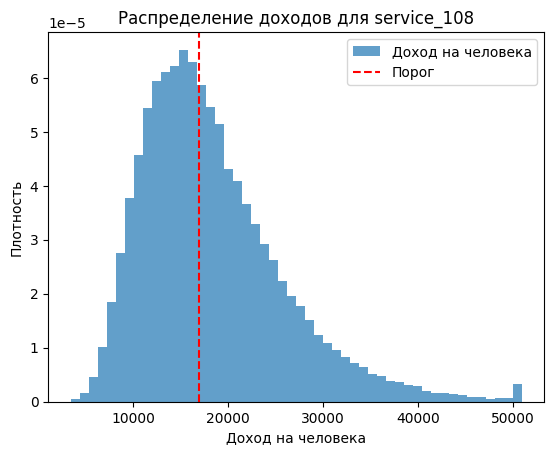

In [17]:
import matplotlib.pyplot as plt

# Фильтр для семей, подходящих по условиям service_108
mask = (data['age'] < 16) | ((data['age'] >= 16) & (data['study_certificate'] == 1))
income_per_person = df[mask]['income_childEveryMonthPosob_Oro'] / df[mask]['family_size']

plt.hist(income_per_person, bins=50, density=True, alpha=0.7, label='Доход на человека')
plt.axvline(x=SDD_border_multiplier_108 * living_wage, color='r', linestyle='--', label='Порог')
plt.xlabel('Доход на человека')
plt.ylabel('Плотность')
plt.title('Распределение доходов для service_108')
plt.legend()
plt.show()

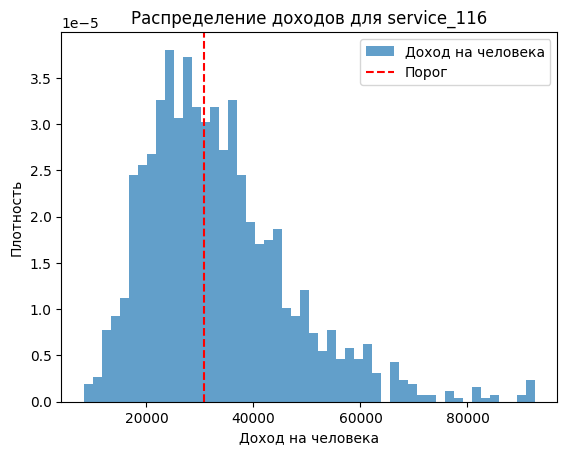

In [18]:
# Фильтр для семей, подходящих по условиям service_116
mask = (df['age'] < 3) & (df['child_number'] >= 3)
income_per_person = df[mask]['income_edvThirdChild'] / df[mask]['family_size']

plt.hist(income_per_person, bins=50, density=True, alpha=0.7, label='Доход на человека')
plt.axvline(x=SDD_border_multiplier_116 * living_wage, color='r', linestyle='--', label='Порог')
plt.xlabel('Доход на человека')
plt.ylabel('Плотность')
plt.title('Распределение доходов для service_116')
plt.legend()
plt.show()